<a href="https://maestriasydiplomados.tec.mx/posgrados/maestria-en-inteligencia-artificial-aplicada"><img src="logo_MR4010.png"></a>
<h1> <div align="center"> Dr. David Antonio-Torres</div> </h1>

# HISTOGRAMA DE GRADIENTES ORIENTADOS (*HISTOGRAM OF ORIENTED GRADIENTS, HOG*)

## Entorno de ejecución y referencias

🔗 **Repositorio GitHub:** [https://github.com/joelbecv/MNA_WORKSPACE](https://github.com/joelbecv/MNA_WORKSPACE)  
📁 **Archivo:** `3.4_SVM_b.ipynb`

### ¿Dónde puedo correr este notebook?

| Entorno | Estado | Tiempo estimado |
|---------|--------|-----------------|
| 💻 Mac M5 (local) | ✅ Funciona | 1-2 min |
| ☁️ Google Colab | ✅ Funciona | 1-2 min |


# Se cargan las bibliotecas necesarias

In [1]:
import cv2
import numpy as np
import matplotlib.image as mpimg
from matplotlib import pyplot as plt
import skimage.feature
from skimage.feature import hog 
%matplotlib inline

# Se carga la imagen de prueba
### https://unsplash.com/s/photos/car-on-street
### Photo by ARTO SURAJ on Unsplash

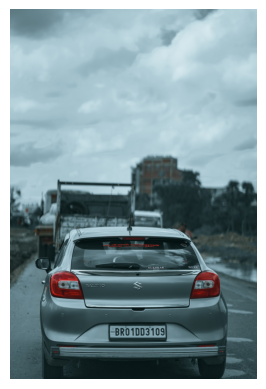

In [2]:

img_bgr = cv2.imread('photo-1663194815175-0f78e4b54ff8.jpeg')
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

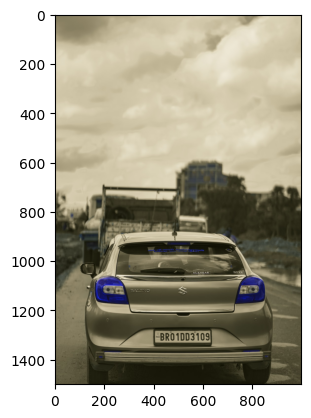

In [3]:
plt.imshow(img_bgr)

# Se obtiene la imagen en escala de grises

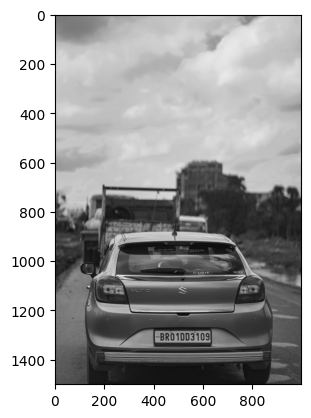

In [4]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap = 'gray')

In [5]:
img_gray.shape

(1500, 1000)

# Se calculan los gradientes en ambas direcciones con Sobel
### https://stackoverflow.com/questions/19815732/what-is-the-gradient-orientation-and-gradient-magnitude

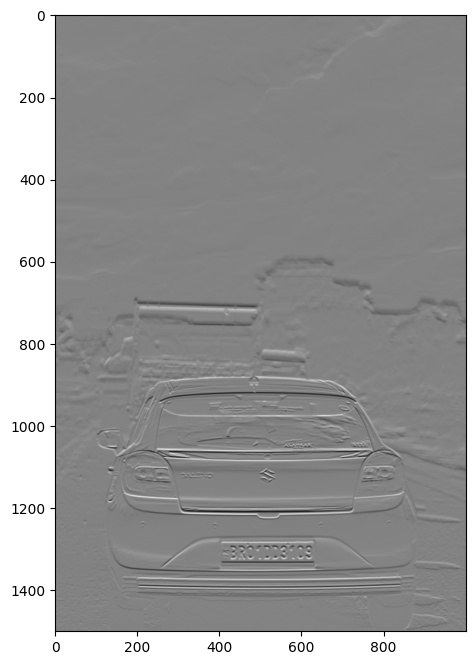

In [6]:
x_sobel = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize = 7)
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
ax.imshow(x_sobel,cmap='gray')

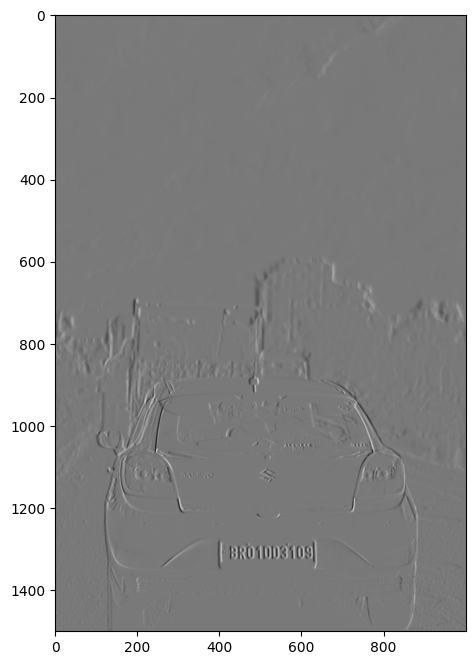

In [7]:
y_sobel = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize = 7)
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)
ax.imshow(y_sobel,cmap='gray')

# Se calcula HOG
### https://learnopencv.com/histogram-of-oriented-gradients/
### https://customers.pyimagesearch.com/lesson-sample-histogram-of-oriented-gradients-and-car-logo-recognition/

In [8]:
features, hog_img = hog(img_gray, 
                        orientations = 9, 
                        pixels_per_cell = (16, 16), 
                        cells_per_block = (1, 1), 
                        transform_sqrt = False, 
                        visualize = True, 
                        feature_vector = False)

In [9]:
features.shape

(93, 62, 1, 1, 9)

In [10]:
hog_img.shape

(1500, 1000)

# Se escalan los niveles de gris de la imagen resultante y se muestra

In [11]:
from skimage import exposure

hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 2))

Text(0.5, 1.0, 'HOG Features')

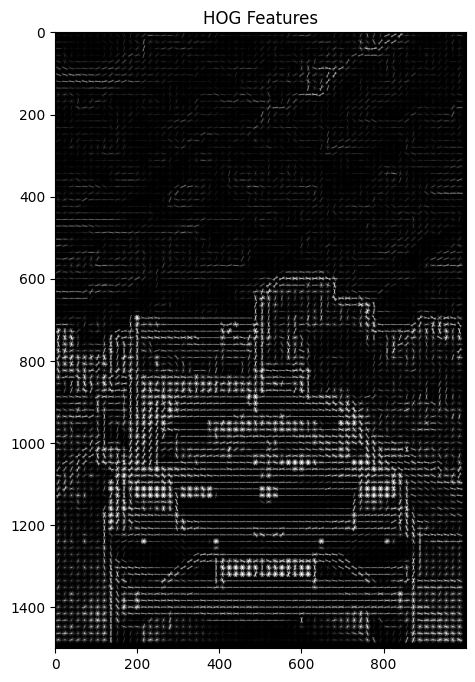

In [12]:
plt.figure(figsize=(10,8))
#ax = fig.add_subplot(111)
plt.imshow(hog_img_rescaled, cmap = 'gray')
plt.title('HOG Features')

# Gracias por la atención